<a href="https://colab.research.google.com/github/ferneysua123-dot/Telecom_X_Parte2/blob/main/TelecomX_PARTE__II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracción del Archivo Tratado

In [ ]:
import pandas as pd
datos= pd.read_csv("datos_tratados.csv")
datos.head()



,ID_Cliente,Abandono,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Varias_Lineas,Tipo_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,Mujer,0,1,1,9,1,0,DSL,...,0,1,1,0,Un año,1,Cheque por correo,65.6,593.30,2.19
1,0003-MKNFE,0,Hombre,0,0,0,9,1,1,DSL,...,0,0,0,1,Mes a mes,0,Cheque por correo,59.9,542.40,2.00
2,0004-TLHLJ,1,Hombre,0,0,0,4,1,0,Fibra optica,...,1,0,0,0,Mes a mes,1,Cheque electronico,73.9,280.85,2.46
3,0011-IGKFF,1,Hombre,1,1,0,13,1,0,Fibra optica,...,1,0,1,1,Mes a mes,1,Cheque electronico,98.0,1237.85,3.27
4,0013-EXCHZ,1,Mujer,1,1,0,3,1,0,Fibra optica,...,0,1,1,0,Mes a mes,1,Cheque por correo,83.9,267.40,2.80


In [ ]:
datos.columns

Index(['ID_Cliente', 'Abandono', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja',
       'Tiene_Dependientes', 'Meses_Permanencia', 'Servicio_Telefonico',
       'Varias_Lineas', 'Tipo_Internet', 'Seguridad_Online', 'Respaldo_Online',
       'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV',
       'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital',
       'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias'],
      dtype='object')

#Eliminación de Columnas Irrelevantes

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

Cargo_Total vs. Meses_Permanencia (0.83):Mantener ambas puede causar "redundancia". Para predecir el abandono, es más útil Meses_Permanencia, Cargo Total es solo una consecuencia del tiempo.

In [ ]:
# Definimos las que se van por ser irrelevantes o redundantes
columnas_irrelevantes = ['ID_Cliente', 'Cuentas_Diarias']
df_modelo = datos.drop(columns=columnas_irrelevantes)
df_modelo.head(2)

,Abandono,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Varias_Lineas,Tipo_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total
0,0,Mujer,0,1,1,9,1,0,DSL,0,1,0,1,1,0,Un año,1,Cheque por correo,65.6,593.3
1,0,Hombre,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Mes a mes,0,Cheque por correo,59.9,542.4


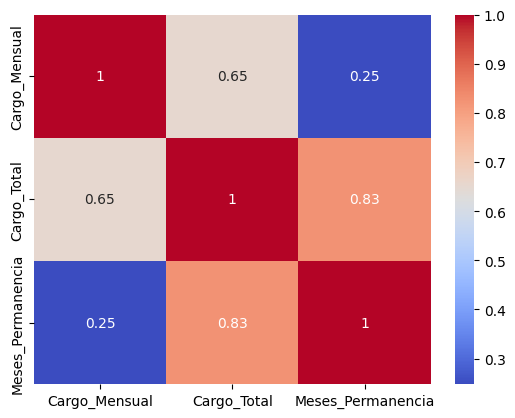

In [ ]:
# Verificando la igualdad de Cargo_Mensual y Cargo_Total son casi iguales
# Creamos el nuevo dataset
correlacion = df_modelo[['Cargo_Mensual', 'Cargo_Total', 'Meses_Permanencia']].corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df_modelo.drop(columns='Cargo_Total').head(2)

,Abandono,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Varias_Lineas,Tipo_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual
0,0,Mujer,0,1,1,9,1,0,DSL,0,1,0,1,1,0,Un año,1,Cheque por correo,65.6
1,0,Hombre,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Mes a mes,0,Cheque por correo,59.9


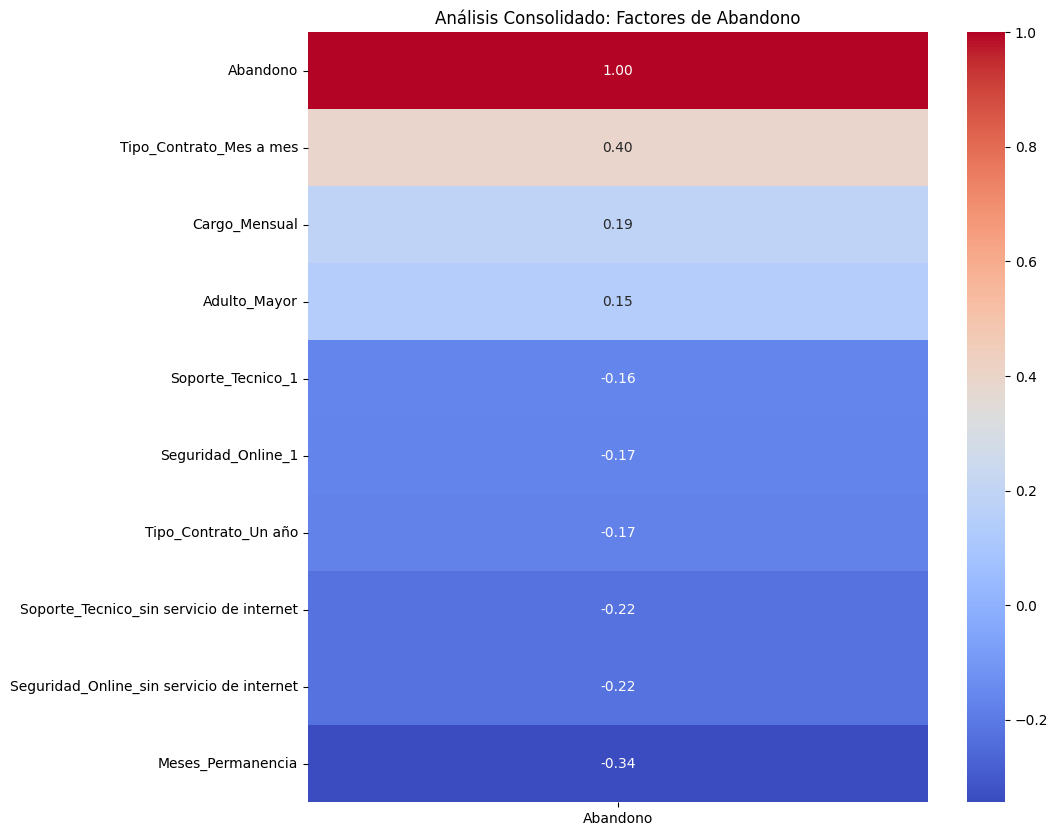

In [ ]:

# Definimos todas las columnas que quieres rescatar para el estudio
columnas_finales = [
    'Abandono', 'Meses_Permanencia', 'Cargo_Mensual', 'Adulto_Mayor',
    'Soporte_Tecnico', 'Seguridad_Online', 'Tipo_Contrato'
]

# 2. Aplicamos dummies (Soporte, Seguridad, Contrato)
# El parámetro 'columns' le dice a pandas qué transformar, el resto las deja igual.
df_preparado = pd.get_dummies(datos[columnas_finales],
                              columns=['Soporte_Tecnico', 'Seguridad_Online', 'Tipo_Contrato'],
                              drop_first=True)

# 3. Graficamos la correlación consolidada
plt.figure(figsize=(10, 10))
correlacion_total = df_preparado.corr()[['Abandono']].sort_values(by='Abandono', ascending=False)

sns.heatmap(correlacion_total, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Análisis Consolidado: Factores de Abandono')
plt.show()


1. El "Disparador" del Abandono: Contrato Mes a Mes (0.40), Es el factor con la correlación positiva más alta.Existe una relación muy clara entre tener un contrato mensual y la probabilidad de irse. Es el factor número uno de fuga. Los clientes no están "atados" y ante cualquier molestia, se marchan.
2. El "Ancla" de Lealtad: Meses de Permanencia (-0.34), es la correlación negativa más fuerte.
Qué significa: A mayor tiempo en la empresa, menor probabilidad de abandono. Los clientes que pasan la "barrera crítica" de los primeros meses se vuelven leales. Tu estrategia debe ser "sobrevivir" con el cliente los primeros 6-12 meses.
3. Los Servicios que Retienen (Valores Negativos)
Seguridad_Online_1, Soporte_Tecnico_1 y Tipo_Contrato_Un año:
Todos tienen números negativos (entre -0.16 y -0.22).
Se debe contratar estos servicios "ancla" al cliente. El cliente que tiene soporte técnico y seguridad se siente más cuidado o percibe más valor, por lo que se va menos que el que no los tiene.
4. Factores de Riesgo Menores
Cargo_Mensual (0.19) y Adulto_Mayor (0.15): No son tan determinantes como el tipo de contrato, pero suman. Los planes caros y el segmento de adultos mayores tienen una tendencia levemente mayor a abandonar el servicio.
#¿Quién se va? Clientes nuevos (poca permanencia), adultos mayores y personas con cargos mensuales altos.
#¿Por qué se van? Principalmente por la falta de compromiso de los contratos mes a mes.
#¿Cómo retenerlos? Empujándolos hacia contratos anuales y ofreciendo (o regalando un tiempo) los servicios de Soporte Técnico y Seguridad Online, ya que actúan como protectores.

In [ ]:
df_preparado.head(2)

,Abandono,Meses_Permanencia,Cargo_Mensual,Adulto_Mayor,Soporte_Tecnico_1,Soporte_Tecnico_sin servicio de internet,Seguridad_Online_1,Seguridad_Online_sin servicio de internet,Tipo_Contrato_Mes a mes,Tipo_Contrato_Un año
0,0,9,65.6,0,True,False,False,False,False,True
1,0,9,59.9,0,False,False,False,False,True,False


In [ ]:
print(df_preparado.dtypes)


Abandono                                       int64
Meses_Permanencia                              int64
Cargo_Mensual                                float64
Adulto_Mayor                                   int64
Soporte_Tecnico_1                               bool
Soporte_Tecnico_sin servicio de internet        bool
Seguridad_Online_1                              bool
Seguridad_Online_sin servicio de internet       bool
Tipo_Contrato_Mes a mes                         bool
Tipo_Contrato_Un año                            bool
dtype: object


In [ ]:
# Convierte todos los True/False a 1/0
df_listo = df_preparado.astype(int)

# Verifica el resultado
print(df_listo.dtypes)


Abandono                                     int64
Meses_Permanencia                            int64
Cargo_Mensual                                int64
Adulto_Mayor                                 int64
Soporte_Tecnico_1                            int64
Soporte_Tecnico_sin servicio de internet     int64
Seguridad_Online_1                           int64
Seguridad_Online_sin servicio de internet    int64
Tipo_Contrato_Mes a mes                      int64
Tipo_Contrato_Un año                         int64
dtype: object


Conteo de clientes:
Abandono
0    5398
1    1869
Name: count, dtype: int64

Proporción porcentual:
Abandono
0    74.280996
1    25.719004
Name: proportion, dtype: float64


/tmp/ipykernel_130/813430380.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Abandono', data=df_listo, palette='viridis')


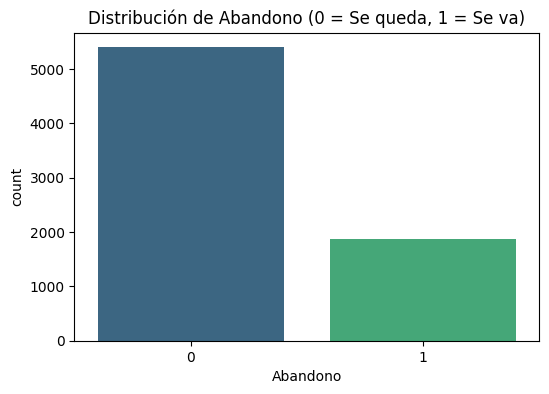

In [ ]:
# 1. Contamos cuántos hay de cada clase
conteo_abandono = df_listo['Abandono'].value_counts()
proporcion_abandono = df_listo['Abandono'].value_counts(normalize=True) * 100

# 2. Mostramos los resultados
print("Conteo de clientes:")
print(conteo_abandono)
print("\nProporción porcentual:")
print(proporcion_abandono)

# 3. Visualización rápida para el reporte
plt.figure(figsize=(6,4))
sns.countplot(x='Abandono', data=df_listo, palette='viridis')
plt.title('Distribución de Abandono (0 = Se queda, 1 = Se va)')
plt.show()
